# sedkit + orblet: an observed joint fit
**Question:** can SED and two RV curves share one physical binary model?

Allow **8 minutes**. We will fit actual Gaia XP and 52 SOPHIE SB2 epochs of
**HD 195987**, expose the likelihood interface, and calculate the light correction
needed for a future astrometric term. No simulated RV or astrometry is used here.

Use Python **3.11 or 3.12**, `sedkit[notebook]`, and the tested orblet revision:
```bash
pip install "orblet @ git+https://github.com/saharsh1/orblet.git@7aa297df4520d1e93c8a7a5a763a1f2d928bfa51"
```
Default execution uses included public observations and makes new outputs in this
notebook directory. There is no live network request.

In [1]:
from pathlib import Path
import sys, json, csv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path(globals().get('__file__', Path.cwd())).resolve()
if ROOT.is_file():
    ROOT = ROOT.parent
while not (ROOT / 'src' / 'sedkit').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'src' / 'sedkit').is_dir():
    raise RuntimeError('Open this notebook from the sedkit checkout.')
sys.path.insert(0, str(ROOT / 'src'))
from sedkit import SED, StellarModel, download, fit, plot
from sedkit.plot import PAPER_STYLE, BINARY, SINGLE

OUT = ROOT / 'examples' / 'group_meeting' / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)
model = StellarModel()

## 1. Fit the observed RV curves with orblet
For the first step, period, eccentricity, periastron phase, both amplitudes and
component offsets are free. The native RV measurement errors remain unchanged.
The component offsets can differ because the measured velocity zero points differ.

In [2]:
import importlib.util, shutil, io
from contextlib import redirect_stdout
from orblet.likelihood import rv_loglike
from orblet.model import semi_amplitude_kms
from orblet.constants import DAYS_PER_KEPLER_YEAR
from orblet.interpret.flux_ratio import signed_photocentre_axis_ratio

example = ROOT / 'examples' / 'real_orblet_20260927'
sys.path.insert(0, str(example))
from fit_rv import fit_rv
joint_dir = OUT / 'hd195987'
joint_dir.mkdir(exist_ok=True)
for filename in ('sed.npz', 'hd195987_rv.csv'):
    shutil.copy2(example / filename, joint_dir / filename)
rv_only = fit_rv(joint_dir)
print(f"RV-only: P={rv_only['parameters']['period_days']:.5f} d, q={rv_only['q']:.6f}")
print(f"Residual RMS: primary={rv_only['rms1_ms']:.2f}, secondary={rv_only['rms2_ms']:.2f} m/s")
print(f"chi2={rv_only['chi2']:.1f} for {rv_only['n_data']} measurements and 8 parameters")

RV-only: P=57.32214 d, q=0.786470
Residual RMS: primary=5.64, secondary=25.73 m/s
chi2=519.0 for 104 measurements and 8 parameters


## 2. Run the conditional shared-parameter fit
sedkit supplies masses, spectra and G-band light ratio; orblet supplies RV predictions
and likelihoods. The SED and RV terms use the same M1 and q.

This small test fixes orbital shape to the RV-only solution and profiles the RV
amplitude and component offsets. M1 and q imply inclination through the Keplerian
amplitude. An orbital-parallax Gaussian supplies the distance; the catalogue Gaia
parallax is retained but not also added. The source has Gaia RUWE = 11.775.

In [3]:
spec = importlib.util.spec_from_file_location('observed_joint_example', example / 'run.py')
joint_demo = importlib.util.module_from_spec(spec)
spec.loader.exec_module(joint_demo)
joint_demo.HERE = joint_dir
with redirect_stdout(io.StringIO()):
    joint_demo.main()
summary = json.loads((joint_dir / 'summary.json').read_text())
r = summary['joint']
print(f"SED-only q={summary['sed_only']['q']:.4f}; joint q={r['q']:.6f}")
print(f"Joint masses: {r['m1']:.4f}, {r['m2']:.4f} solar masses")
print(f"Inclination: {r['inclination_deg']:.2f} or {r['mirror_inclination_deg']:.2f} deg")
print(f"Age={r['age_gyr']:.2f} Gyr; [M/H]={r['feh']:.3f}; bounds={r['at_bounds']}")
print('Published comparison masses: 0.844 +/- 0.018 and 0.6650 +/- 0.0079 solar masses')

SED-only q=0.7898; joint q=0.786470
Joint masses: 0.8341, 0.6560 solar masses
Inclination: 81.76 or 98.24 deg
Age=10.00 Gyr; [M/H]=-0.027; bounds=['age_gyr']
Published comparison masses: 0.844 +/- 0.018 and 0.6650 +/- 0.0079 solar masses


## 3. The actual likelihood interface
`loglike_sed` evaluates a proposal, with model covariance and no built-in distance prior.
For each RV likelihood, `mass_msun` is the **companion mass times sin(i)**;
`M_msun` remains the true total mass. The secondary omega is primary omega + pi.
Periods are converted from days to years.

The table supplies BJD; we use BJD minus 2400000.5 and the matching periastron time
for these relative Keplerian calculations. They are not Gaia TCB epochs.

In [4]:
from sedkit import loglike_sed
sed = SED.load(joint_dir / 'sed.npz')
rv = np.genfromtxt(joint_dir / 'hd195987_rv.csv', delimiter=',', names=True)
times = rv['bjd'] - 2400000.5
orbit = summary['rv_only']['parameters']
m1, q = r['m1'], r['q']
sin_i = np.sin(np.deg2rad(r['inclination_deg']))
common = dict(period_yr=orbit['period_days']/DAYS_PER_KEPLER_YEAR,
              ecc=orbit['ecc'], tau=0., epoch_ref_mjd=orbit['tp_bjd_minus_2400000_5'],
              M_msun=m1*(1+q), jitter_kms=0.)
ll_sed = loglike_sed(sed, m1=m1, q=q, age_gyr=r['age_gyr'], feh=r['feh'],
                    parallax_mas=r['parallax_mas'], model=model)
ll_rv1 = rv_loglike(times, rv['rv1_kms'], rv['err1_kms'],
                    mass_msun=m1*q*sin_i, omega_rad=orbit['omega_rad'],
                    offset_kms=r['gamma1_kms'], **common)
ll_rv2 = rv_loglike(times, rv['rv2_kms'], rv['err2_kms'],
                    mass_msun=m1*sin_i, omega_rad=orbit['omega_rad']+np.pi,
                    offset_kms=r['gamma2_kms'], **common)
distance = summary['distance_constraint']
ll_distance = -.5*((r['parallax_mas']-distance['parallax_mas'])/distance['error_mas'])**2
ll_joint = ll_sed + ll_rv1 + ll_rv2 + ll_distance
np.testing.assert_allclose(-2*ll_joint, r['objective'], rtol=1e-10)
print(f'Joint log likelihood (fixed constants omitted): {ll_joint:.3f}')

Joint log likelihood (fixed constants omitted): -234.851


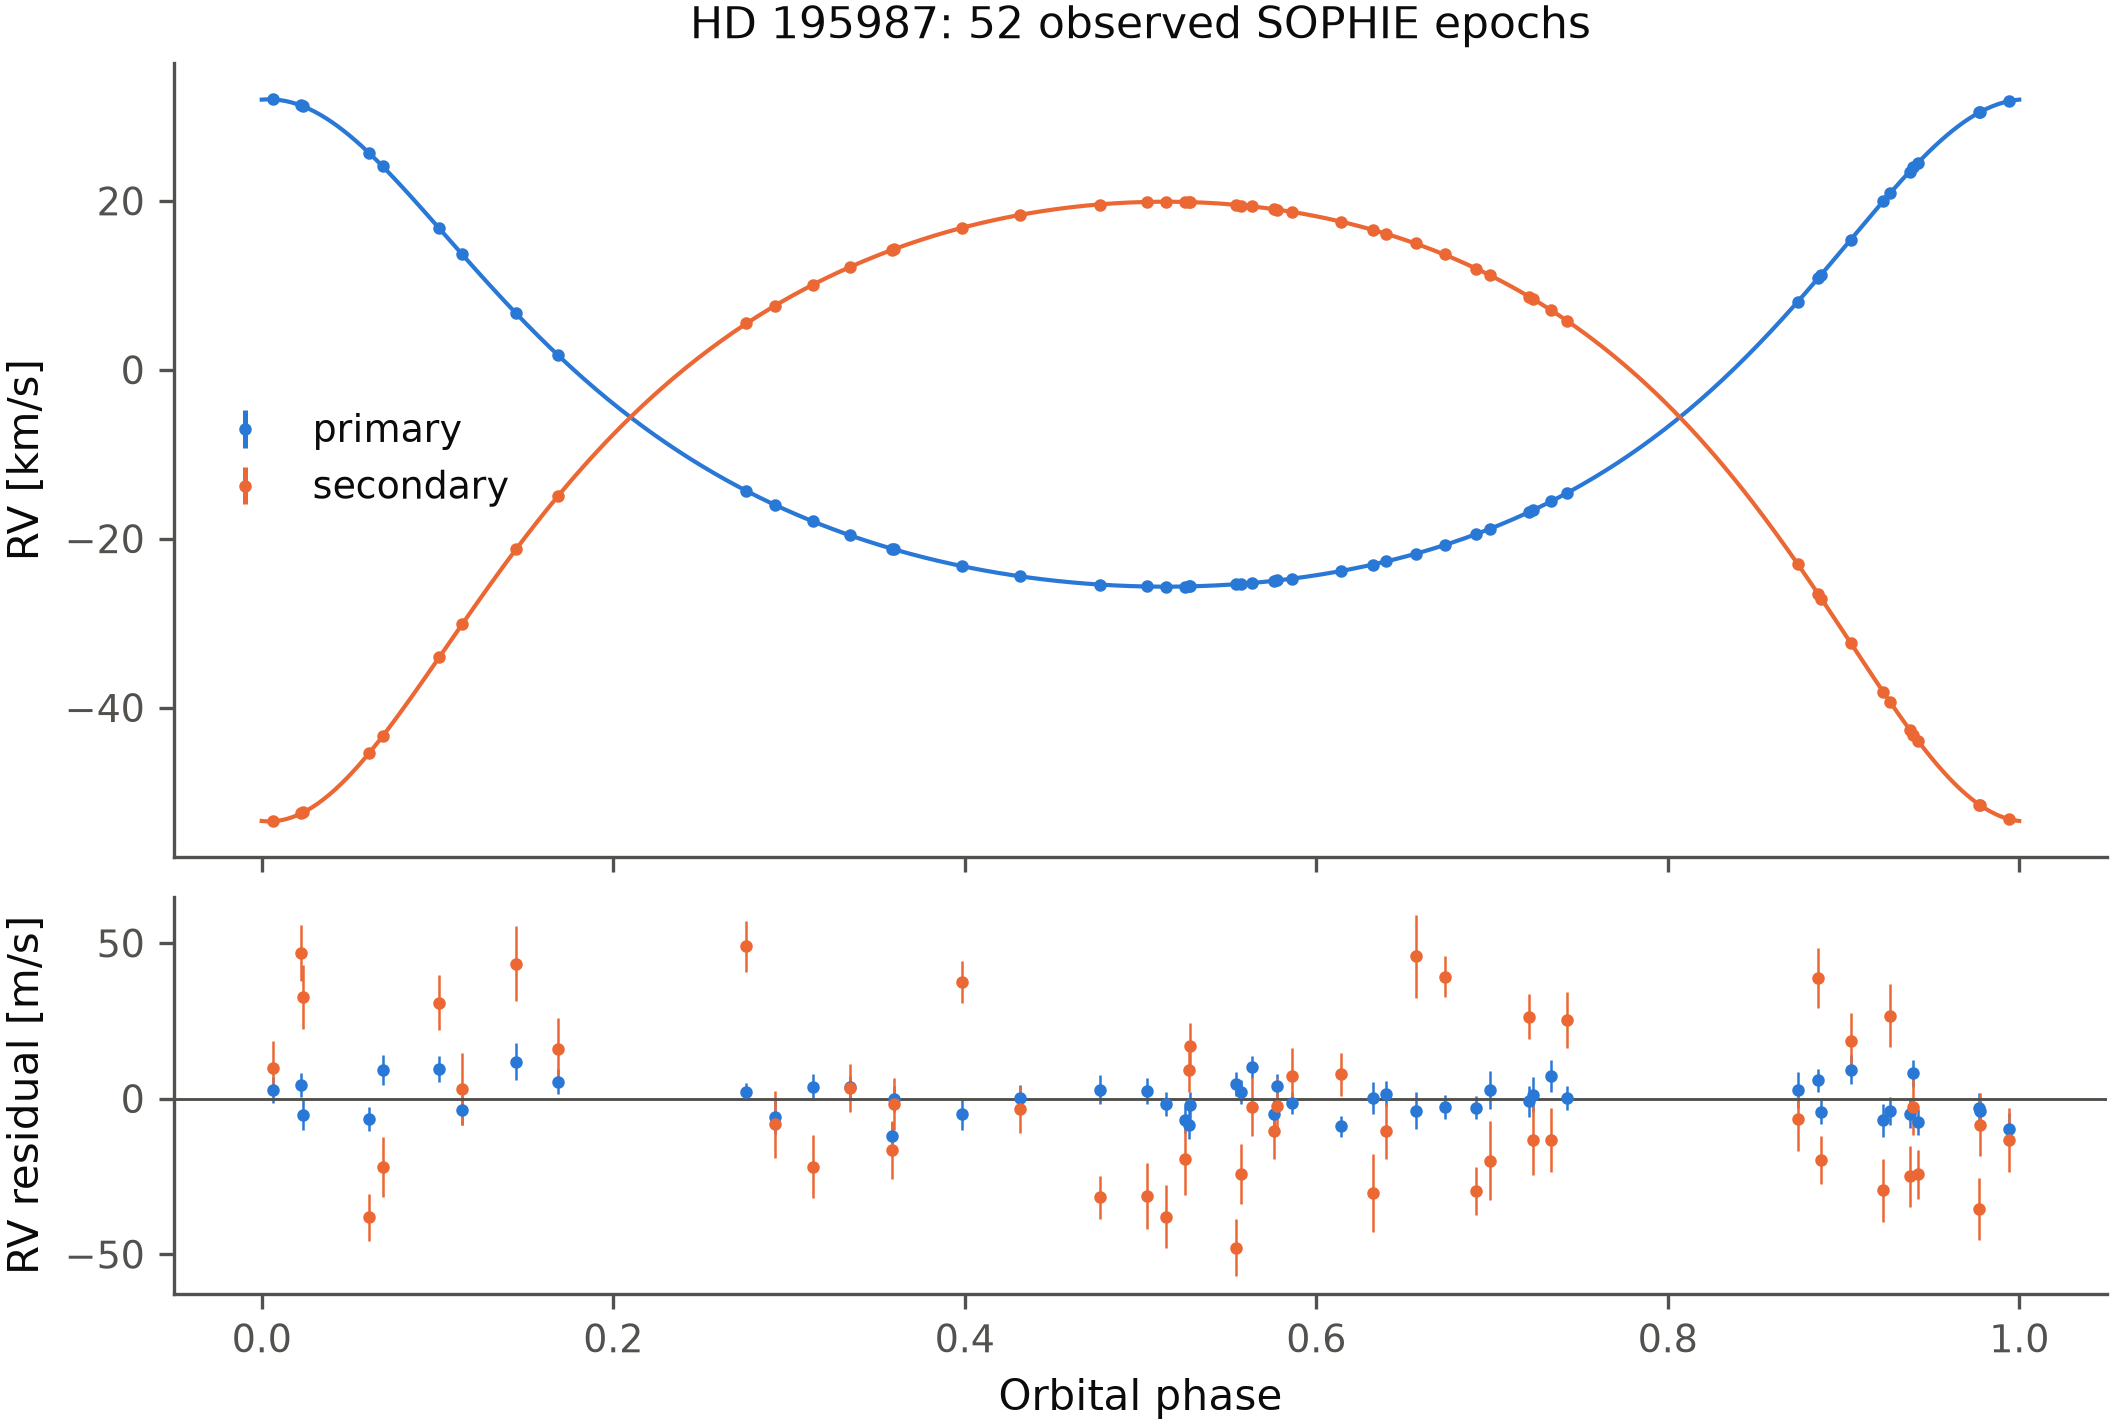

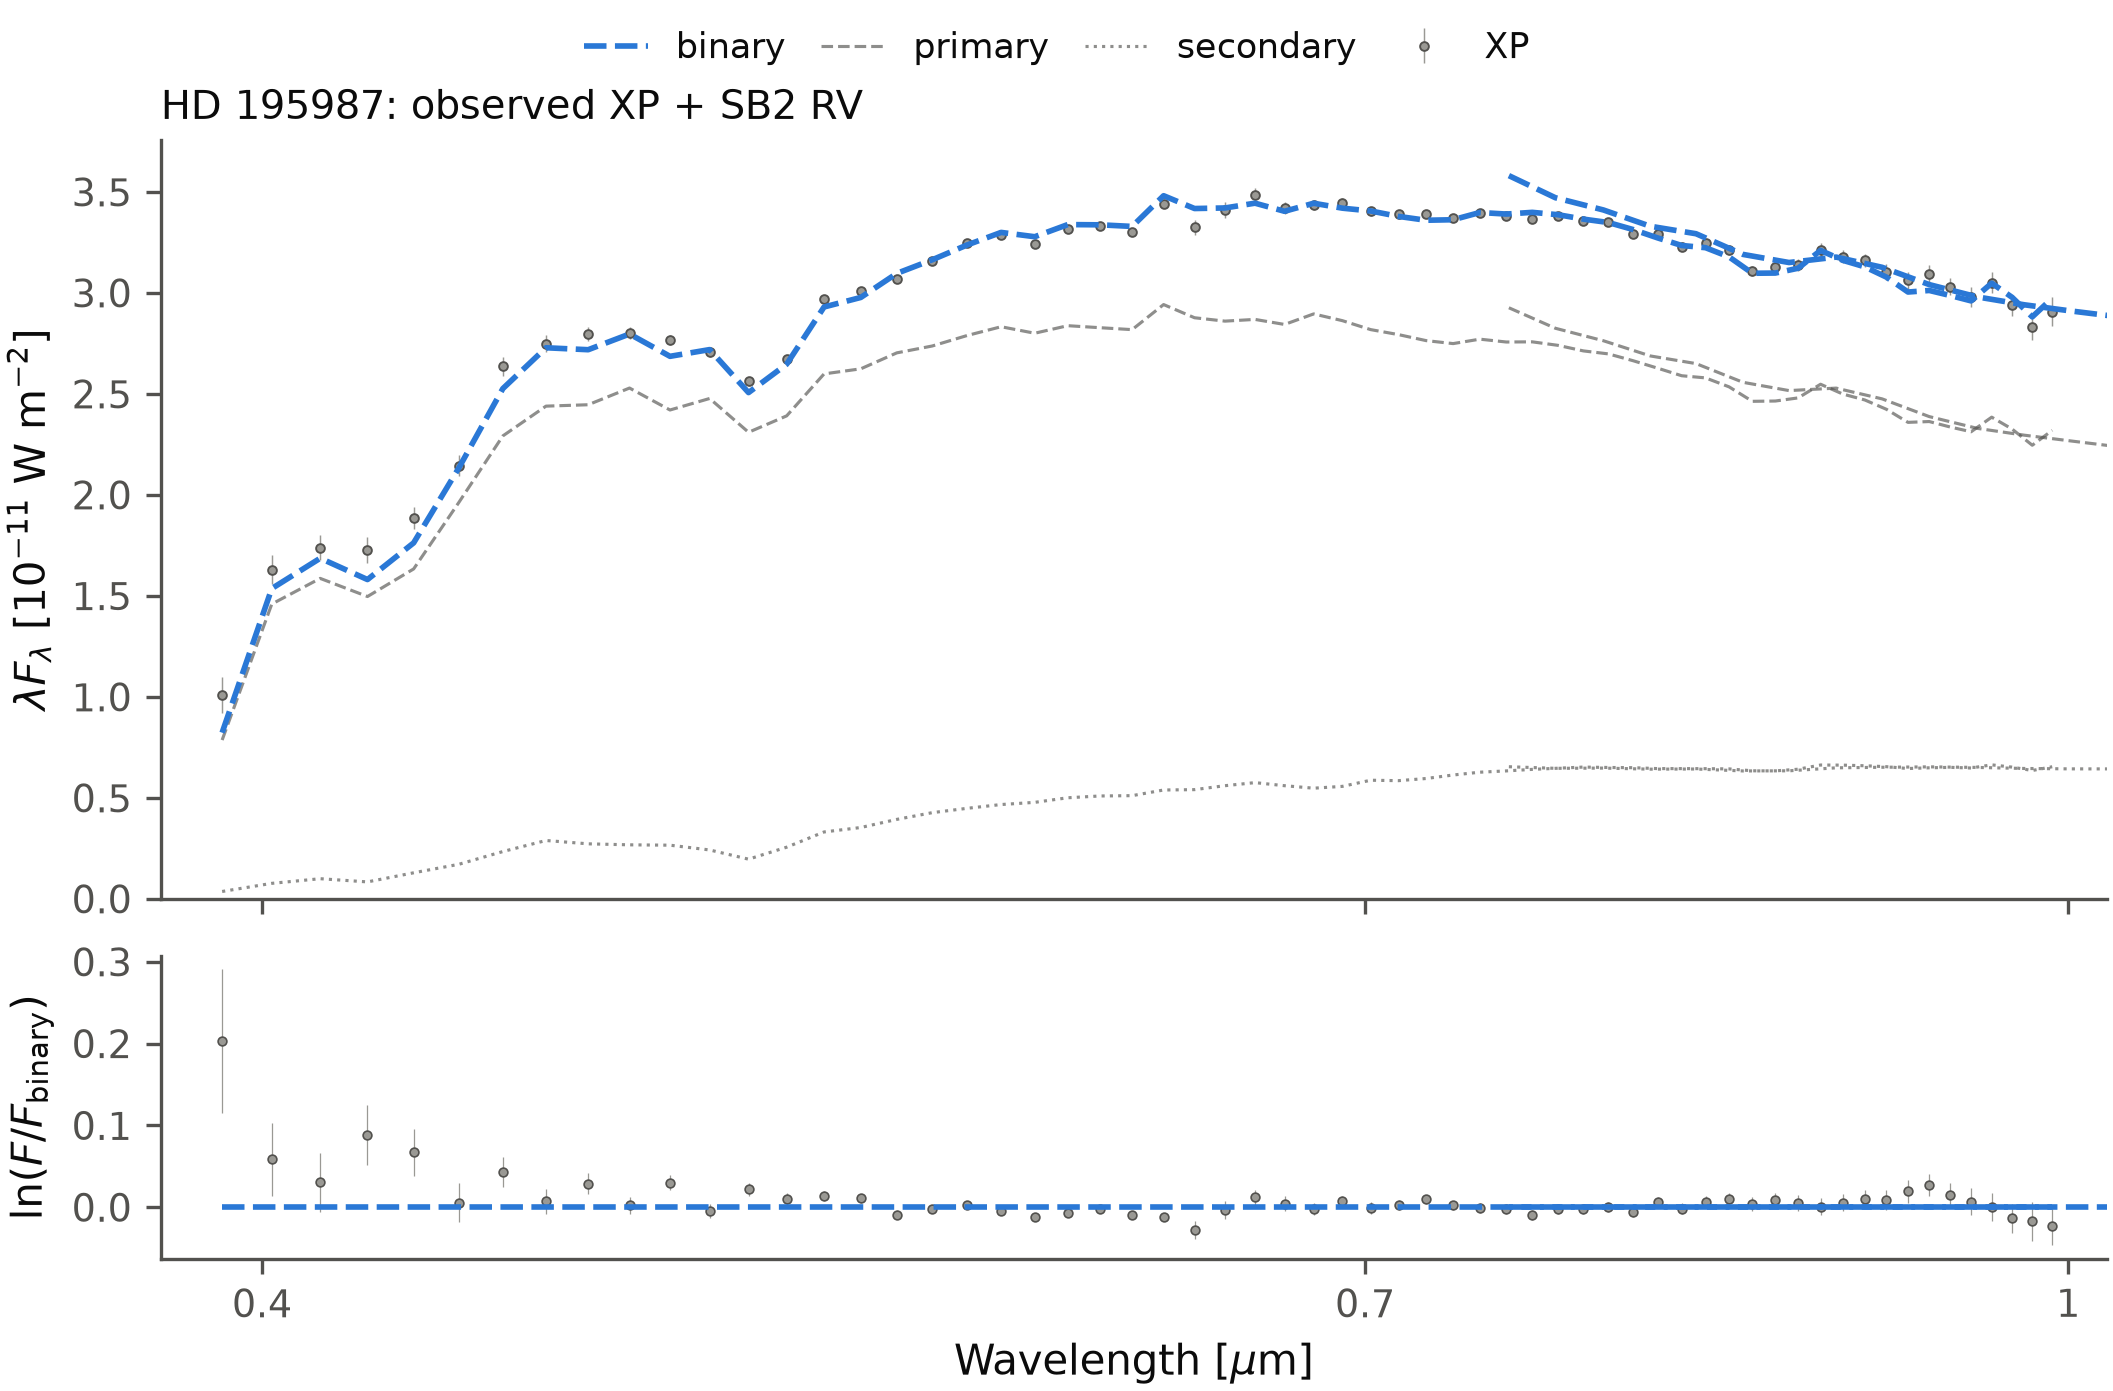

In [5]:
display(Image(filename=str(joint_dir / 'rv.png')))
display(Image(filename=str(joint_dir / 'sed.png')))

## 4. What would Gaia astrometry measure?
RVs follow each star; unresolved Gaia astrometry follows the **photocentre**.
`beta_g` means F_G,2 / F_G,1, not the secondary fraction of total light.
For a primary-frame orbit, multiply the primary displacement by
`(q - beta_g) / (q * (1 + beta_g))` before `along_scan_model`.
The equal-mass, equal-light case has no photocentre motion.

The curve below is a **model response**, not observed Gaia epoch astrometry.

G-band light ratio beta=0.182; photocentre/primary displacement=0.650


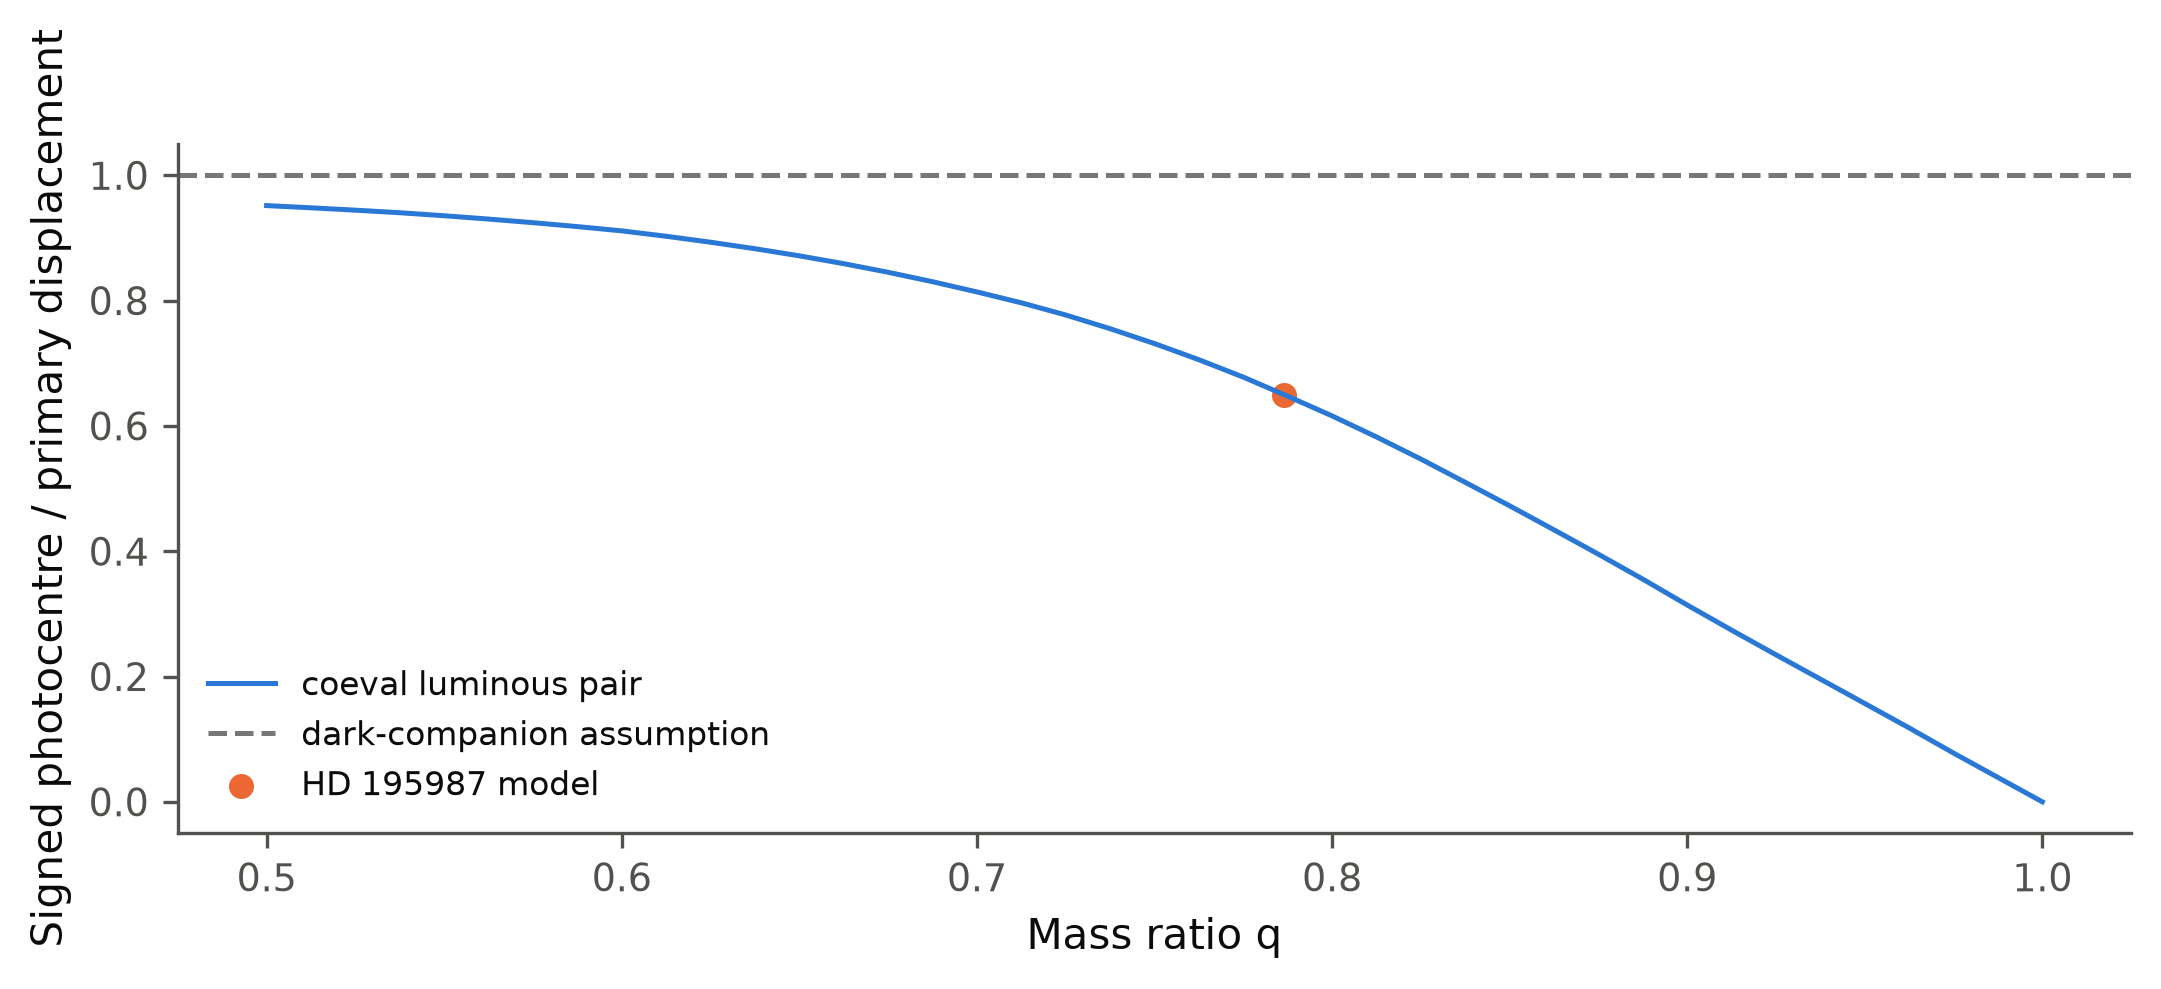

In [6]:
pair = model.evaluate(m1, q, r['age_gyr'], r['feh'])
beta, factor = pair['beta_g'], pair['a_phot_over_a1']
np.testing.assert_allclose(factor, signed_photocentre_axis_ratio(q, beta))
print(f'G-band light ratio beta={beta:.3f}; photocentre/primary displacement={factor:.3f}')
ratios = np.linspace(.5, 1., 41)
factors = []
for ratio in ratios:
    prediction = model.evaluate(m1, ratio, r['age_gyr'], r['feh'])
    factors.append(np.nan if prediction is None else prediction['a_phot_over_a1'])
with plt.rc_context(PAPER_STYLE):
    fig, ax = plt.subplots(figsize=(7.087, 2.8), layout='constrained')
    ax.plot(ratios, factors, color=BINARY, label='coeval luminous pair')
    ax.axhline(1., color='#777777', ls='--', label='dark-companion assumption')
    ax.scatter([q], [factor], color=SINGLE, s=25, label='HD 195987 model')
    ax.set(xlabel='Mass ratio q', ylabel='Signed photocentre / primary displacement')
    ax.legend(fontsize=8)
    for extension in ('png', 'pdf'):
        fig.savefig(OUT / ('03_photocentre.' + extension), dpi=300, bbox_inches='tight')
    plt.close(fig)
display(Image(filename=str(OUT / '03_photocentre.png')))
np.testing.assert_allclose(model.evaluate(m1, 1., r['age_gyr'], r['feh'])['a_phot_over_a1'], 0.)

## What this example tells us
The public likelihood interfaces compose on actual XP and SB2 data. q is dominated
by the precise RV amplitude ratio. The recovered masses are close to literature
values, but this is not an independent mass-accuracy measurement: the distance
constraint and comparison masses share the historical interferometric analysis.

Age reaches 10 Gyr; other optimizer starts retain local minima. The secondary RV
scatter exceeds its reported errors, and the blue end of XP retains residuals.
The Gaussian, Newtonian fit has no jitter, relativistic terms, extinction,
alpha-enhancement or orbit-shape uncertainty. There are no posterior mass errors.

**Discussion:** why not add the catalogue parallax when Gaia epoch astrometry is fitted?
It reuses information derived from those same epochs. This example contains no epoch
astrometry and instead uses one external orbital-parallax constraint.

**Next small test:** free the RV orbital shape and compare an explicit residual model
while retaining the original measurement errors.

[Observed joint-fit provenance](../../docs/real-orblet.md) ·
[orblet mapping and conditional mock](../../docs/orblet.md).

Figure-generating code: [03_orblet_joint_fit.py](03_orblet_joint_fit.py).